In [21]:
# load a matrix from a space-separated file and show it as an image
import sys
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/')
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import os
from stat_utils import bic_gaussian_from_rmse
from memory_upd_utils import polarity, extract_mem_updates, extract_adaptation_measurements
from optimise_clnn import load_subject_data

result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_tryMU2/'

In [22]:


a_exp = np.loadtxt(os.path.join(result_path, 'a_exp.txt'))
a_pred = np.loadtxt(os.path.join(result_path, 'a_pred.txt'))


seeds = 5
subjs = a_exp.shape[1] // seeds

In [23]:
rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0)).reshape([subjs, seeds])
n_samples = np.sum(~np.isnan(a_exp),axis=0).reshape([subjs, seeds])
#ensure n_samples is same in every row
assert np.all(n_samples == n_samples[:, [0]])
n_samples = n_samples[:, 0]

best_seed_idx = np.argmin(rmse, axis=1)
best_rmse = np.min(rmse, axis=1)

In [24]:
n_samples

array([292, 292, 292, 292, 292, 292, 292, 292, 292, 292, 292, 292, 292,
       292, 292, 292, 292, 292, 292, 292, 292, 292, 292, 292])

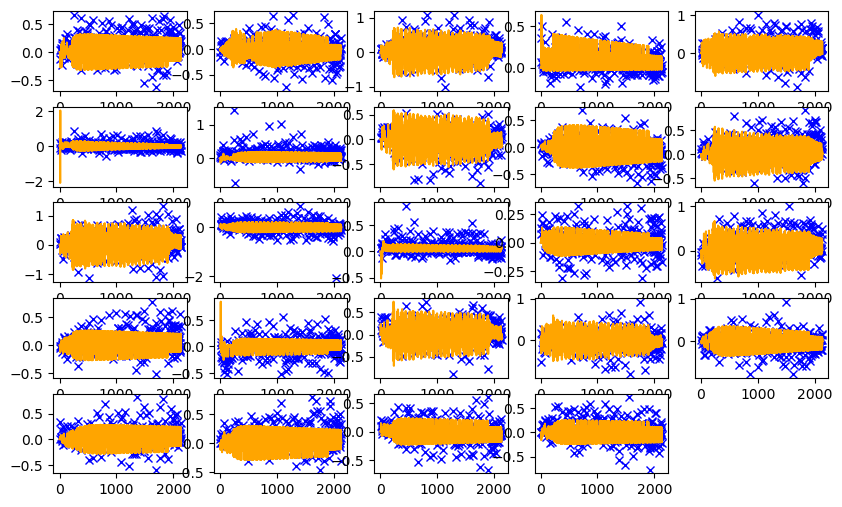

In [25]:
preds = {}
plt.figure(figsize=(10, 6))
plt.subplot(5, 5, 1)
for ii, (this_exp, this_pred) in enumerate(zip(a_exp.T, a_pred.T)):
    plt.subplot(5, 5, 1 + ii//seeds)
    if ii % seeds == 0:
        plt.plot(this_exp,'x', label='Experimental', color='blue')
    if ii % seeds == best_seed_idx[ii//seeds]:
        plt.plot(this_pred, label='Predicted', color='orange')
        preds[ii//seeds+1] = this_pred
    # plt.xlabel('trials')
    # plt.ylabel('adaptation')
    # plt.title('Experimental vs Predicted Data')

In [26]:
experimental_data = {}
loss_traces= {}
output_traces= {}
prior_out_batch = {}
posterior_out_batch = {}
for i in range(1,25): 
    experimental_data[i] = load_subject_data(f'/homes/ar2342/frogs_project/data/COIN_data/trial_data_memory_updating_participant{i}.csv')

In [27]:
outs = []
outs_ini = []
fit_outs = []
fit_outs_ini = []

for i in range(1, 25):
            ys = experimental_data[i][1]
            qs = experimental_data[i][2]
            aa = experimental_data[i][0]
            outs.append(extract_mem_updates(ys, qs, aa,-32))
            outs_ini.append(extract_mem_updates(ys, qs, aa,16))
            # fit_outs.append(extract_mem_updates(ys, qs, mean_as[i-1],-32))
            these_preds = np.mean(preds[i], axis=1) if len(preds[i].shape) > 1 else preds[i]
            try:
                fit_outs.append(extract_mem_updates(ys, qs, these_preds,-32))
                fit_outs_ini.append(extract_mem_updates(ys, qs, these_preds,16))
            except:
                # fit_outs.append(None)
                pass

# rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0)).reshape([subjs, seeds])
# n_samples = np.sum(~np.isnan(a_exp),axis=0).reshape([subjs, seeds])
# best_seed_idx = np.argmin(rmse, axis=1)
# best_rmse = rmse[np.arange(subjs), best_seed_idx]

Text(0.5, 1.0, 'model')

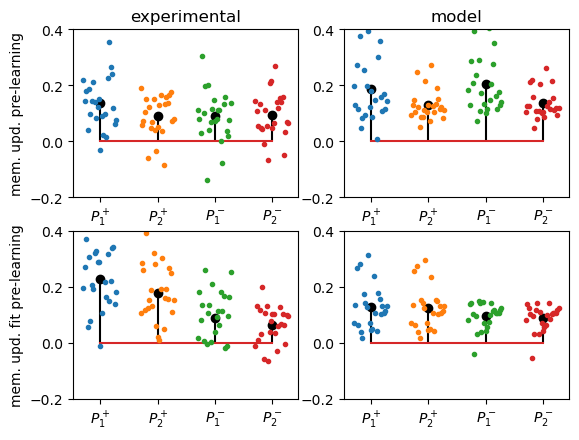

In [28]:
mode_names = ['$P^+_1$', '$P^+_2$', '$P^-_1$', '$P^-_2$']
y_alignment = np.array([1,1,-1,-1])

for ii, these_outs in enumerate([outs_ini, fit_outs_ini, outs, fit_outs]):
    plt.subplot(2,2,ii+1)
    plt.stem(y_alignment * np.mean(these_outs, axis=-1).mean(axis=0), 'xk')
    for ii in range(4):
        xdata = -0.3+0.6/24*np.arange(24) + ii
        ydata = y_alignment[ii] * np.mean(these_outs, axis=-1)[:,ii]
        plt.plot(xdata, ydata,'.')
    plt.ylim([-0.2, 0.4])

    # plt.ylim([-0.1, 0.6])
    plt.xticks(np.arange(4), mode_names)
    # plt.ylabel('memory update')
plt.subplot(2,2,1); plt.ylabel('mem. upd. pre-learning')
plt.subplot(2,2,3); plt.ylabel('mem. upd. fit pre-learning')
plt.subplot(2,2,1); plt.title('experimental')
plt.subplot(2,2,2); plt.title('model')


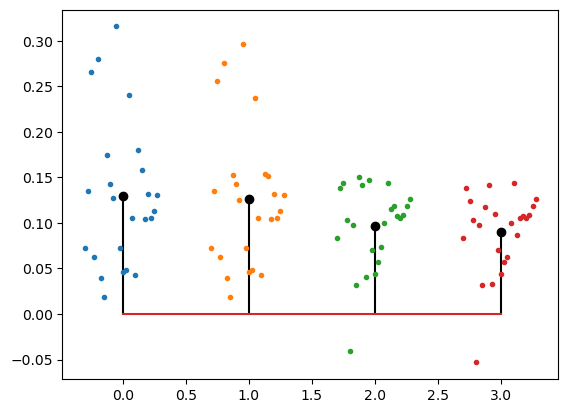

In [29]:
these_outs = fit_outs
plt.stem(y_alignment * np.mean(these_outs, axis=-1).mean(axis=0), 'xk')
for ii in range(4):
    xdata = -0.3+0.6/24*np.arange(24) + ii
    ydata = y_alignment[ii] * np.mean(these_outs, axis=-1)[:,ii]
    plt.plot(xdata, ydata,'.')

In [30]:
y_alignment * np.mean(these_outs, axis=-1).mean(axis=0)

array([0.12975876, 0.12583014, 0.0969566 , 0.09020726])

In [31]:
outs = []
outs_ini = []
fit_outs = []
fit_outs_ini = []

ada = []
fit_ada = []

for i in range(1, 25):
            ys = experimental_data[i][1]
            qs = experimental_data[i][2]
            aa = experimental_data[i][0]
            outs.append(extract_mem_updates(ys, qs, aa,-32))
            outs_ini.append(extract_mem_updates(ys, qs, aa,16))
            ada.append(extract_adaptation_measurements(ys, qs, aa))
            # fit_outs.append(extract_mem_updates(ys, qs, mean_as[i-1],-32))
            these_preds = np.mean(preds[i], axis=1) if len(preds[i].shape) > 1 else preds[i]
            try:
                fit_outs.append(extract_mem_updates(ys, qs, these_preds,-32))
                fit_outs_ini.append(extract_mem_updates(ys, qs, these_preds,16))
                fit_ada.append(extract_adaptation_measurements(ys, qs, these_preds))
            except:
                # fit_outs.append(None)
                pass


(-0.05, 0.85)

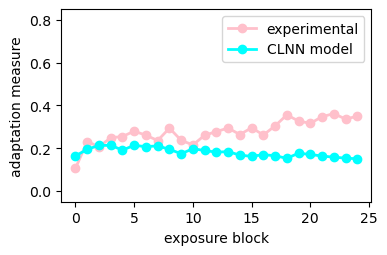

In [32]:
ada_all = [this_ada[1] for this_ada in ada] + [-1*np.array(this_ada[-1]) for this_ada in ada] 
fit_ada_all = [this_ada[1] for this_ada in fit_ada] + [-1*np.array(this_ada[-1]) for this_ada in fit_ada]
plt.figure(figsize=(4,2.5))
plt.plot(np.mean(ada_all, axis=0), label='experimental', color='pink', linewidth=2, marker='o')
plt.plot(np.mean(fit_ada_all, axis=0), label='CLNN model', color='cyan', linewidth=2, marker='o')
plt.xlabel('exposure block')
plt.ylabel('adaptation measure')
plt.legend()
plt.ylim([-0.05, 0.85])